In [1]:
import os
import os.path as osp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.random import seed
import math
import winsound
import sklearn as sk
from sklearn.feature_selection import f_regression
import scipy
import pingouin as pg
import sys
import mne 

sys.path.insert(1, '..\\..\\')

from preprocess import *
from pipelines import *
from classifieur import *
from read_data import *


def beep():
    winsound.Beep(440, 500)
    winsound.Beep(330, 400)
    winsound.Beep(550, 500)

    return None


In [2]:
mne.set_log_level(verbose="Warning") # set all the mne verbose to warning
seed(2002011) # set seed for reproducibility

In [3]:



# ==============================================================================
print("collecting data")
init_path = "..\..\..\..\Dataset\Big_dataset\\"
participant_dir, files_dir = read_bigdataset_data(init_path)
#
participant_dir = participant_dir
files_dir = files_dir

# participant_dir = [participant_dir[0:1][0][0:3]]
# files_dir = files_dir[0:1]

print("la ", participant_dir)
print(files_dir)

dic_data = collect_data(files_dir, participant_dir, init_path)

session = []
for i in range(len(files_dir)):
    for j in range(len(participant_dir[i])):
        session += [participant_dir[i][j] + "_" + str(trial) for trial in range(1, 7)]

participant_dir = [participant for session in participant_dir for participant in session]
print(participant_dir)

dic_covariate = {}

print(" extract relative gamma ")


print("filtering data")
steps_preprocess = {"filter": [8, 30],
                    "drop_channels": ['EOG1', 'EOG2', 'EOG3', 'EMGg', 'EMGd']}

for key in dic_data.keys():
    _ = preprocess(dic_data[key], steps_preprocess)

session_test = [sess[:9] for sess in session]
list_session = np.unique(session_test)

# pipelines = get_pipeline() # go to the file pipeline.py to select the pipeline you want to use


collecting data
you have succesfuly acces to the directory :  ..\..\..\..\Dataset\Big_dataset\
['DATA A', 'DATA B', 'DATA C']
[['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A2', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A3', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A4', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A5', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A6', 'A60', 'A7', 'A8', 'A9'], ['B61', 'B62', 'B63', 'B64', 'B65', 'B66', 'B67', 'B68', 'B69', 'B70', 'B71', 'B72', 'B73', 'B74', 'B75', 'B76', 'B77', 'B78', 'B79', 'B80', 'B81'], ['C82', 'C83', 'C84', 'C85', 'C86', 'C87']]
la  [['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A2', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A3', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A4', 'A41', 'A42', 'A43', 'A44',

In [4]:
steps_epoching = {"tmin": 0.5, "tmax": 4.5, "overlap": 1, "lenght":4,
                 "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}




In [5]:
session_test

['A1_1',
 'A1_2',
 'A1_3',
 'A1_4',
 'A1_5',
 'A1_6',
 'A10_1',
 'A10_2',
 'A10_3',
 'A10_4',
 'A10_5',
 'A10_6',
 'A11_1',
 'A11_2',
 'A11_3',
 'A11_4',
 'A11_5',
 'A11_6',
 'A12_1',
 'A12_2',
 'A12_3',
 'A12_4',
 'A12_5',
 'A12_6',
 'A13_1',
 'A13_2',
 'A13_3',
 'A13_4',
 'A13_5',
 'A13_6',
 'A14_1',
 'A14_2',
 'A14_3',
 'A14_4',
 'A14_5',
 'A14_6',
 'A15_1',
 'A15_2',
 'A15_3',
 'A15_4',
 'A15_5',
 'A15_6',
 'A16_1',
 'A16_2',
 'A16_3',
 'A16_4',
 'A16_5',
 'A16_6',
 'A17_1',
 'A17_2',
 'A17_3',
 'A17_4',
 'A17_5',
 'A17_6',
 'A18_1',
 'A18_2',
 'A18_3',
 'A18_4',
 'A18_5',
 'A18_6',
 'A19_1',
 'A19_2',
 'A19_3',
 'A19_4',
 'A19_5',
 'A19_6',
 'A2_1',
 'A2_2',
 'A2_3',
 'A2_4',
 'A2_5',
 'A2_6',
 'A20_1',
 'A20_2',
 'A20_3',
 'A20_4',
 'A20_5',
 'A20_6',
 'A21_1',
 'A21_2',
 'A21_3',
 'A21_4',
 'A21_5',
 'A21_6',
 'A22_1',
 'A22_2',
 'A22_3',
 'A22_4',
 'A22_5',
 'A22_6',
 'A23_1',
 'A23_2',
 'A23_3',
 'A23_4',
 'A23_5',
 'A23_6',
 'A24_1',
 'A24_2',
 'A24_3',
 'A24_4',
 'A24_5',
 '

In [6]:

pipelines = {}

pipelines['6 csp+lda'] = make_pipeline(CSP(n_components=6), LDA())

list_run = [3, 4, 5, 6]

df_accuracy = pd.DataFrame(None, columns=["subject" , "accuracy"])
i = 0

In [7]:

for pipeline in pipelines.values():

    classifieur = Within_Session(pipelines, session_test, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True, dataset="Big_Dataset")
    for subject in participant_dir:
        # print(subject)
        j += 1
        classifieur._subject = subject
        X_train, Y_train, _,  X_test, Y_test, _ = classifieur.extract_train_test()
        pipeline.fit(X_train, Y_train)
        y_pred = pipeline.transform(X_test)
        score = pipeline.score(X_test,Y_test)
        # print(score)
        # Creating a new DataFrame for the row to add
        new_row = pd.DataFrame({'subject': [subject], 'accuracy': [score]})
        
        # Adding the new row to the dataframe using pandas.concat
        df_accuracy = pd.concat([df_accuracy, new_row], ignore_index=True)




        # correlation_run[subject] = np.corrcoef(y_pred, Covariate_test, rowvar=False)[0,1]

    # print(correlation_run)

# all_data["y"].loc[all_data["y"]  == 0 ] = -1
# all_data["SMR_quality_score"] = all_data["y_pred"] * all_data["y"]
# all_data["good_prediction"] = all_data["SMR_quality_score"] > 0
df_accuracy

epoching: 100%|██████████| 4/4 [00:00<00:00, 45.45it/s]


,subject,accuracy
0,A1,0.83750
1,A10,0.82500
2,A11,0.61875
3,A12,0.52500
4,A13,0.70625
...,...,...
80,C83,0.87500
81,C84,0.68750
82,C85,0.84375
83,C86,0.68125


In [8]:
df_accuracy.mean()

C:\Users\dtrocell\AppData\Local\Temp\ipykernel_4672\1014298378.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_accuracy.mean()


accuracy    0.679338
dtype: float64

epoching: 100%|██████████| 4/4 [00:00<00:00, 42.53it/s]


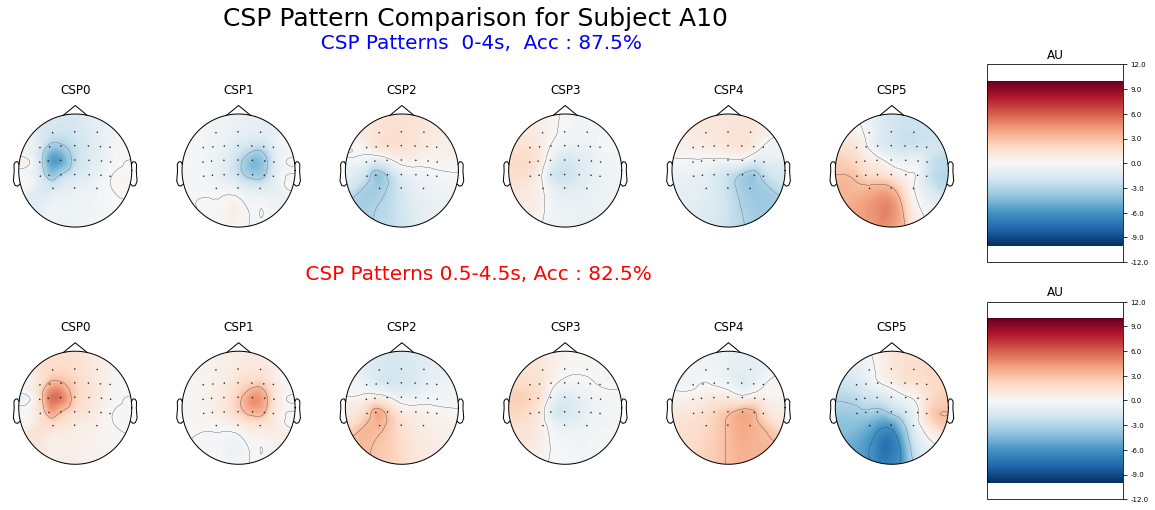

In [35]:
steps_epoching = {"tmin": 0, "tmax": 4, "overlap": 1, "lenght": 4,
                  "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}

classifieur_0_4 = Within_Session(pipelines, session_test, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True, dataset="Big_Dataset")

steps_epoching = {"tmin": 0.5, "tmax": 4.5, "overlap": 1, "lenght": 4,
                  "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}

classifieur_05_45 = Within_Session(pipelines, session_test, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True, dataset="Big_Dataset")

# steps_epoching = {"tmin": 0, "tmax": .5, "overlap": 1, "lenght": 4,
#                   "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}
# 
# classifieur_0_05 = Within_Session(pipelines, session_test, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True)

epoch_info = dic_data["A10_1"]  # Adjusted to use the loop variable
ten_twenty_montage = mne.channels.make_standard_montage('standard_1020')
epoch_info.set_montage(ten_twenty_montage)

nb_subjects =1 
df_accuracy =  pd.DataFrame(None, columns=["acc_0_4" , "acc_05_45"] , index=participant_dir)

for subject_idx in range(1, nb_subjects+1):  # Loop from A1 to A10
    subject = participant_dir[subject_idx]
    pipeline = make_pipeline(CSP(n_components=6), LDA())

    classifieur_0_4._subject = subject
    classifieur_05_45._subject = subject
    
    
    # Plot CSP patterns without the 'title' keyword argument
    fig, axes = plt.subplots(2, 7, figsize=(20, 8))  # 7 subplots: 6 for CSP patterns + 1 for the color bar
    fig.suptitle(f'CSP Pattern Comparison for Subject {subject}', fontsize=25, color='black', y=0.98 ,x=0.45)



    # Extract train and test data (assuming extract_train_test is appropriately defined for handling different subjects)
    X_train, Y_train, _, X_test, Y_test, _ = classifieur_0_4.extract_train_test()


    # Initialize and fit CSP
    csp = CSP(n_components=6)
    _ = csp.fit(X_train, Y_train)
    csp.plot_patterns(epoch_info.info, axes=axes[0], show_names=False , ch_type="eeg", vlim=(-10,10), nrows=6, show=False)
    # axes[0, 3].set_title(f"CSP Patterns 0-4s for {subject}", fontsize=10, pad=20)
    
    #compute the score for visualisation
    pipeline.fit(X_train, Y_train)
    score_0_4 = pipeline.score(X_test,Y_test)
    df_accuracy.loc[subject, "acc_0_4"] = score_0_4
    
    # Extract train and test data (assuming extract_train_test is appropriately defined for handling different subjects)
    X_train, Y_train, _, X_test, Y_test, _ = classifieur_05_45.extract_train_test()
    # Initialize and fit CSP
    csp = CSP(n_components=6)
    _ = csp.fit(X_train, Y_train)
    
    #compute the score for visualisation
    pipeline.fit(X_train, Y_train)
    score_05_45 = pipeline.score(X_test,Y_test)
    df_accuracy.loc[subject, "acc_05_45"] = score_05_45
    
    csp.plot_patterns(epoch_info.info, axes=axes[1], show_names=False , ch_type="eeg", vlim=(-10,10), show=False)
    # axes[1, 3].set_title(f"CSP Patterns 0.5-4.5s for {subject}", fontsize=10, pad=20)
    fig.text(0.45, 0.9, f'  CSP Patterns  0-4s,  Acc : {score_0_4*100:.1f}%', ha='center', va='bottom', fontsize=20, color="blue")
    fig.text(0.45, 0.5, f' CSP Patterns 0.5-4.5s, Acc : {score_05_45*100:.1f}%', ha='center', va='bottom', fontsize=20,color="red")
    

    plt.savefig(f'Results/{subject}_csp_filters.png', bbox_inches = "tight",  dpi=300)

    plt.show()


    axes[0, -1].axis('off')
    axes[1, -1].axis('off')


# Use the last subplot for the colorbar and hide its axis (no direct plot)
    # The colorbar is automatically added to the last plot of the csp.plot_patterns, so we might not need to manually adjust it



KeyError: 'ax.tick_params is not a valid rc parameter (see rcParams.keys() for a list of valid parameters)'

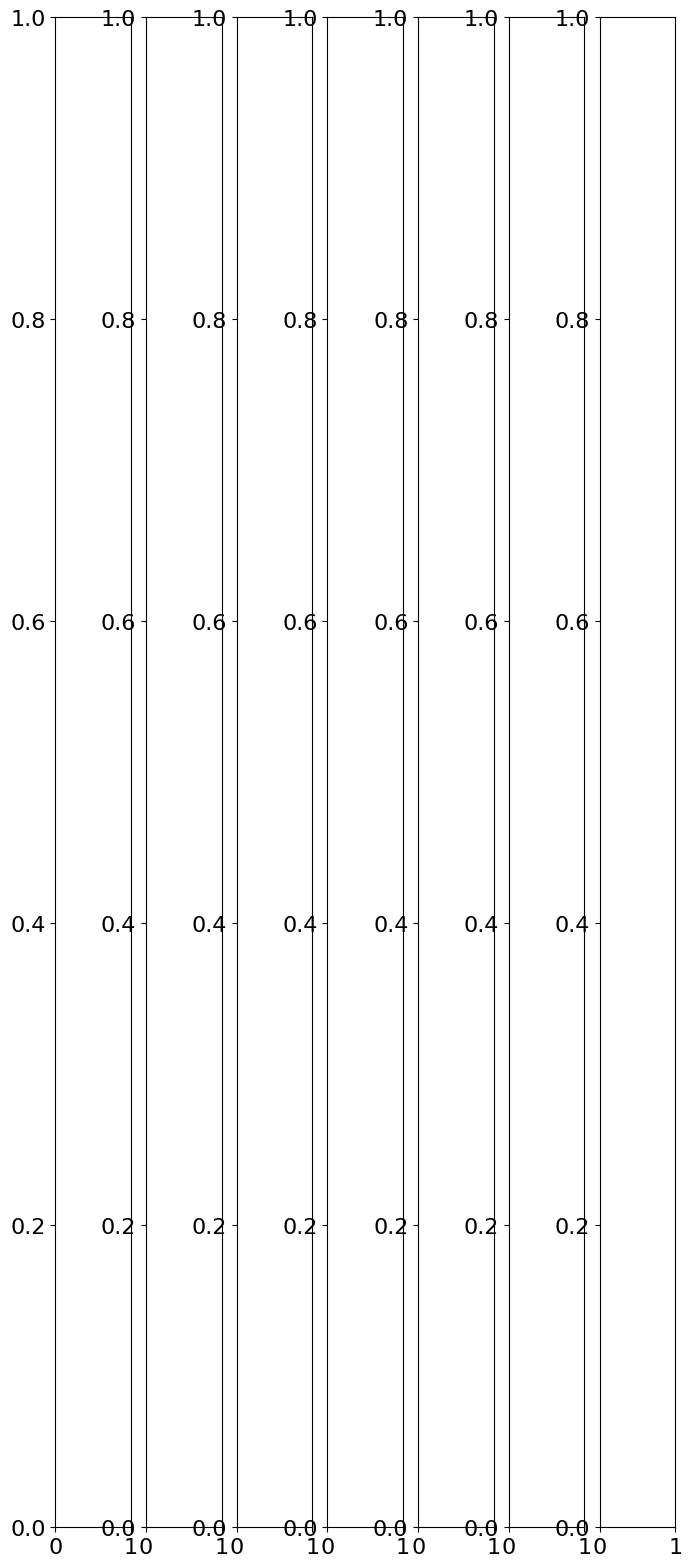

In [42]:
fig, axes = plt.subplots(1,7 , figsize=(8, 20), dpi=100)  # 7 subplots: 6 for CSP patterns + 1 for the color bar
plt.rcParams.update({
    'font.size': 30,               # Base font size
    'axes.titlesize': 25,         # Title font size
    'axes.labelsize': 25,         # Axis label font size
    'xtick.labelsize': 16,        # X-tick label font size
    'ytick.labelsize': 16,        # Y-tick label font size
    'legend.fontsize': 16,        # Legend font size (if used)
    'ax.tick_params':20,
})
csp.plot_patterns(epoch_info.info, show_names=False , axes=axes[0:7], ch_type="eeg", vlim=(-10,10), nrows=6, size =3,  show=True, colorbar=True)



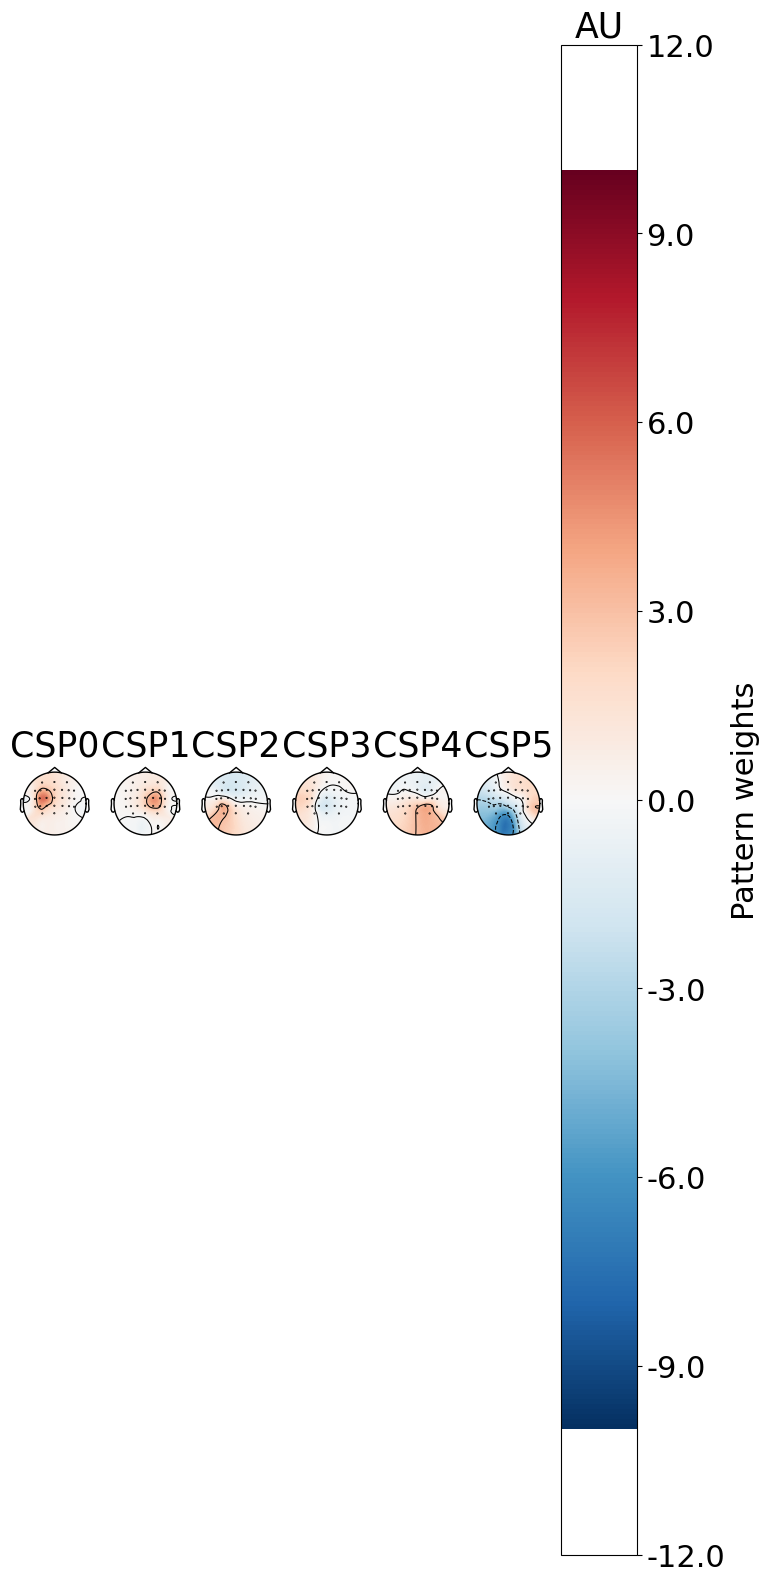

In [53]:
fig, axes = plt.subplots(1,7 , figsize=(8, 20), dpi=100)  # 7 subplots: 6 for CSP patterns + 1 for the color bar

out = csp.plot_patterns(
    epoch_info.info,
    show_names=False,
    axes=axes[0:7],
    ch_type="eeg",
    vlim=(-10, 10),
    nrows=6,
    size=3,
    show=False,
    colorbar=True
)

# Access the colorbar
cbar = axes[-1]  # usually the last element is the colorbar
cbar.tick_params(labelsize=22)  # change tick labels
cbar.set_ylabel("Pattern weights", fontsize=22)
# cbar.set_label("Pattern weights", fontsize=22)  # change colorbar label size
plt.show()

In [10]:
steps_epoching = {"tmin": 0, "tmax": 4, "overlap": 1/16, "lenght": 1,
                  "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}

classifieur_0_4 = Within_Session(pipelines, session_test, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True, dataset="Big_Dataset")
classifieur_0_4._subject = subject

X_train, Y_train, _, X_test, Y_test, _ = classifieur_0_4.extract_train_test()


epoching: 100%|██████████| 4/4 [00:02<00:00,  1.54it/s]


In [11]:
# df_accuracy.to_csv("Results/csp_acc_4s_within.csv")
df_accuracy.mean()

acc_0_4      0.7750
acc_05_45    0.8375
dtype: float64

In [12]:
beep()

A10


epoching:  71%|███████   | 356/504 [00:07<00:03, 48.06it/s]

KeyboardInterrupt



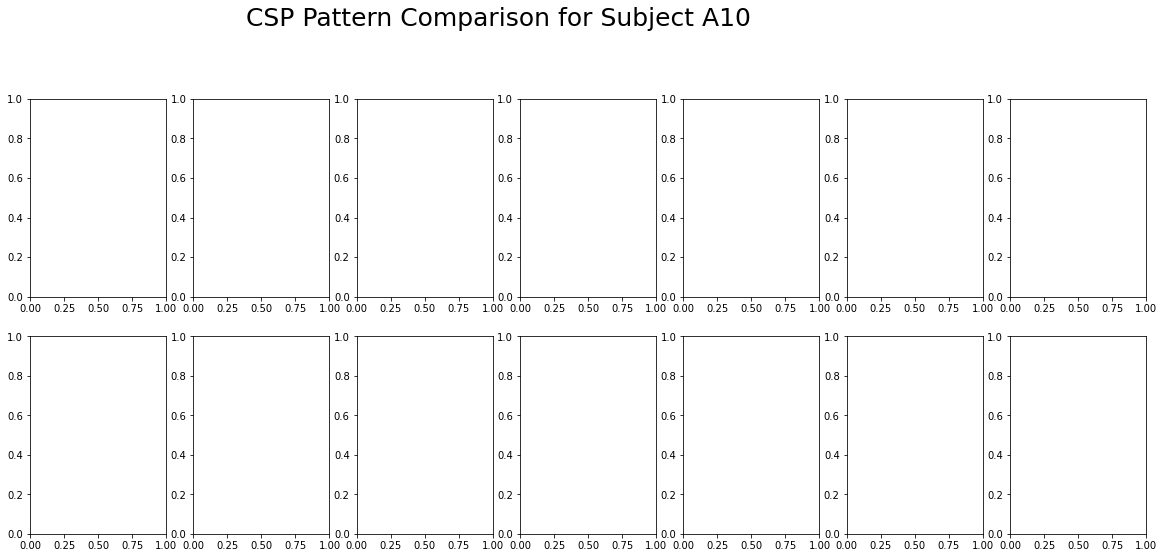

In [15]:
steps_epoching = {"tmin": 0, "tmax": 4, "overlap": 1, "lenght": 4,
                  "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}

classifieur_0_4 = Cross_Subject(pipelines, session_test, participant_dir, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True, dataset="Big_Dataset")


steps_epoching = {"tmin": 0.5, "tmax": 4.5, "overlap": 1, "lenght": 4,
                  "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}

classifieur_05_45 = Cross_Subject(pipelines, session_test, participant_dir, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True)

# steps_epoching = {"tmin": 0, "tmax": .5, "overlap": 1, "lenght": 0.5,
#                   "n_chans": 27, "n_events_per_trial": 40, "one_hot": False}
# 
# classifieur_0_05 = Cross_Subject(pipelines, session_test, participant_dir, steps_epoching, dic_data, dic_covariate = None , filters = None, metadata_run = True, dataset="Big_Dataset")

epoch_info = dic_data["A10_1"]  # Adjusted to use the loop variable
ten_twenty_montage = mne.channels.make_standard_montage('standard_1020')
epoch_info.set_montage(ten_twenty_montage)

df_accuracy =  pd.DataFrame(None, columns=["acc_0_4" , "acc_05_45"] , index=participant_dir)

nb_subjects = 5
for subject_idx in range(1, 2):  # Loop from A1 to A10
    subject = participant_dir[subject_idx]
    print(subject)
    train_key = [f"{subject}_1", f"{subject}_2"]
    classifieur_0_4._subject = subject
    classifieur_05_45._subject = subject
    pipeline = make_pipeline(CSP(n_components=6), LDA())



# Plot CSP patterns without the 'title' keyword argument
    fig, axes = plt.subplots(2, 7, figsize=(20, 8))  # 7 subplots: 6 for CSP patterns + 1 for the color bar
    fig.suptitle(f'CSP Pattern Comparison for Subject {subject}', fontsize=25, color='black', y=1.04 ,x=0.45)

    # Extract train and test data (assuming extract_train_test is appropriately defined for handling different subjects)
    X_train, Y_train, _, X_test, Y_test, _ = classifieur_0_4.extract_train_test()
    # Initialize and fit CSP
    csp = CSP(n_components=6)
    _ = csp.fit(X_train, Y_train)
    csp.plot_patterns(epoch_info.info, axes=axes[0], show_names=False , ch_type="eeg", vlim=(-12,12), show=False)
    #compute the score for visualisation
    pipeline.fit(X_train, Y_train)
    score_0_4 = pipeline.score(X_test,Y_test)
    df_accuracy.loc[subject, "acc_0_4"] = score_0_4


    # Extract train and test data (assuming extract_train_test is appropriately defined for handling different subjects)
    X_train, Y_train, _, X_test, Y_test, _ = classifieur_05_45.extract_train_test()
    # Initialize and fit CSP
    csp = CSP(n_components=6)
    _ = csp.fit(X_train, Y_train)
    csp.plot_patterns(epoch_info.info, axes=axes[1], show_names=False , ch_type="eeg", vlim=(-10,10), show=False)

    #compute the score for visualisation
    pipeline.fit(X_train, Y_train)
    score_05_45 = pipeline.score(X_test,Y_test)
    df_accuracy.loc[subject, "acc_05_45"] = score_05_45

# axes[1, 3].set_title(f"CSP Patterns 0.5-4.5s for {subject}", fontsize=10, pad=20)
    fig.text(0.45, 0.9, f'  CSP Patterns  0-4s for subject {subject} \n Acc : {score_0_4*100:.1f}%', ha='center', va='bottom', fontsize=20,color="blue")
    fig.text(0.45, 0.48, f' CSP Patterns 0.5-4.5s for subject {subject} \n Acc : {score_05_45*100:.1f}%', ha='center', va='bottom', fontsize=20,color="red")
    
    # plt.tight_layout()
    
    plt.savefig(f'Results/{subject}_csp_filters_cross_subject.png', bbox_inches = "tight",  dpi=300)

    plt.show()


    axes[0, -1].axis('off')
    axes[1, -1].axis('off')
    
    


# Use the last subplot for the colorbar and hide its axis (no direct plot)
# The colorbar is automatically added to the last plot of the csp.plot_patterns, so we might not need to manually adjust it



In [ ]:
# df_accuracy.to_csv("Results/csp_acc_cross_subject.csv")
df_accuracy.mean()

In [29]:
beep()